# Summative Lab: DataVine Analytics – Customer Insights & Machine Learning

This starter notebook uses two prepared retail datasets derived from the Online Retail II transactional data:

- `customer_level_online_retail.csv`
- `product_level_online_retail.csv`

You will:
1. Load and inspect both datasets
2. Join them into one analytical dataset
3. Build a **k-NN classification** model to predict customer value segment
4. Build a **product recommendation system**
5. Perform **customer clustering** with K-Means and GMM

**Important:** Keep your code concise, but explain your thinking in comments and markdown.

## Step 0: Import libraries

Add any additional imports you need, but try to keep your notebook focused and readable.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

## Step 1: Load, explore, and prepare the data

Load the two CSV files and inspect their structure.

In [2]:

# TODO: Load the customer-level and product-level datasets.
# Hint: Use pd.read_csv() with the two CSV file names provided for the lab.

customer_df = pd.read_csv("C:/Users/HK/Desktop/FI Data Science/Labs and Assignment/Machine Learning with Scikit-Learn/customer_level_online_retail.csv")
product_df = pd.read_csv("C:/Users/HK/Desktop/FI Data Science/Labs and Assignment/Machine Learning with Scikit-Learn/product_level_online_retail.csv")
# Display the first few rows of each dataset so you can see what fields are available.
print("Customer-level dataset:")
display(customer_df.head())

print("\nProduct-level dataset:")
display(product_df.head())


Customer-level dataset:


,CustomerID,Country,FirstPurchaseDate,LastPurchaseDate,NumInvoices,TotalUnits,TotalSpend,UniqueProducts,FavoriteStockCode,FavoriteProductDescription,...,DiversityRatio,TopCategoryShare,CategoryDiversity,Share_StorageBags,Share_GeneralGifts,Share_HomeDecor,Share_KitchenDining,Share_StationeryCrafts,CountryGroup,ValueSegment
0,12346,United Kingdom,2009-12-14 08:34:00,2011-01-18 10:01:00,12,74285,77556.46,27,TEST001,This is a test product.,...,0.000363,0.999058,4,0.000000,0.000902,0.000000,0.999058,0.000000,UK,High
1,12347,Iceland,2010-10-31 14:20:00,2011-12-07 15:52:00,8,3286,5633.32,126,84558A,3D DOG PICTURE PLAYING CARDS,...,0.038344,0.351187,9,0.256239,0.351187,0.111990,0.093731,0.055386,Europe,High
2,12348,Finland,2010-09-27 14:59:00,2011-09-25 13:13:00,5,2714,2019.40,25,POST,POSTAGE,...,0.009211,0.447310,5,0.282977,0.447310,0.137067,0.000000,0.128224,Europe,High
3,12349,Italy,2010-04-29 13:20:00,2011-11-21 09:51:00,4,1624,4428.69,138,22555,PLASTERS IN TIN STRONGMAN,...,0.084975,0.250000,8,0.179187,0.250000,0.152094,0.190271,0.160714,Europe,High
4,12350,Norway,2011-02-02 16:01:00,2011-02-02 16:01:00,1,197,334.40,17,21908,CHOCOLATE THIS WAY METAL SIGN,...,0.086294,0.583756,3,0.182741,0.583756,0.000000,0.233503,0.000000,Europe,Low



Product-level dataset:


,StockCode,Description,Category,AvgUnitPrice,PriceStd,TotalUnitsSold,TotalRevenue,NumInvoices,UniqueCustomers,CountriesSoldTo,AvgQuantityPerInvoice,CustomerPenetration,RevenuePerCustomer,UnitsPerCustomer,InvoicePenetration
0,10002,INFLATABLE POLITICAL GLOBE,General Gifts,0.841388,0.032384,8624,6761.52,297,164,12,29.037037,0.027901,41.228780,52.585366,0.008034
1,10080,GROOVY CACTUS INFLATABLE,General Gifts,0.509259,0.205425,303,124.61,26,23,1,11.653846,0.003913,5.417826,13.173913,0.000703
2,10109,BENDY COLOUR PENCILS,Stationery & Crafts,0.420000,0.000000,4,1.68,1,1,1,4.000000,0.000170,1.680000,4.000000,0.000027
3,10120,DOGGY RUBBER,General Gifts,0.210000,0.000000,664,139.44,62,52,2,10.709677,0.008847,2.681538,12.769231,0.001677
4,10123C,HEARTS WRAPPING TAPE,Home Decor,0.624000,0.117526,632,229.36,46,39,5,13.739130,0.006635,5.881026,16.205128,0.001244


In [3]:
# Inspect shape
print("Customer dataset shape:", customer_df.shape)
print("Product dataset shape:", product_df.shape)

# Inspect columns
print("\nCustomer dataset columns:\n", customer_df.columns)
print("\nProduct dataset columns:\n", product_df.columns)

# Check missing values
print("\nMissing values in customer dataset:\n", customer_df.isnull().sum())
print("\nMissing values in product dataset:\n", product_df.isnull().sum())

# No missing values in columns.
# Some columns appear to be categorical. 
# No major issues 

Customer dataset shape: (5878, 28)
Product dataset shape: (4631, 15)

Customer dataset columns:
 Index(['CustomerID', 'Country', 'FirstPurchaseDate', 'LastPurchaseDate',
       'NumInvoices', 'TotalUnits', 'TotalSpend', 'UniqueProducts',
       'FavoriteStockCode', 'FavoriteProductDescription', 'FavoriteCategory',
       'AvgOrderValue', 'RecencyDays', 'CustomerTenureDays',
       'AvgUnitsPerInvoice', 'SpendPerProduct', 'PurchaseFrequency',
       'RecencyRatio', 'DiversityRatio', 'TopCategoryShare',
       'CategoryDiversity', 'Share_StorageBags', 'Share_GeneralGifts',
       'Share_HomeDecor', 'Share_KitchenDining', 'Share_StationeryCrafts',
       'CountryGroup', 'ValueSegment'],
      dtype='str')

Product dataset columns:
 Index(['StockCode', 'Description', 'Category', 'AvgUnitPrice', 'PriceStd',
       'TotalUnitsSold', 'TotalRevenue', 'NumInvoices', 'UniqueCustomers',
       'CountriesSoldTo', 'AvgQuantityPerInvoice', 'CustomerPenetration',
       'RevenuePerCustomer', 'UnitsPe

### Join the datasets

In this lab, you will join customer-level information to product-level information using the customer's favorite stock code.

**Join key:** `FavoriteStockCode = StockCode`

In [4]:

# TODO: Join the two datasets.
# Remove duplicate StockCode rows from product table
product_df_dedup = product_df.drop_duplicates(subset="StockCode").copy()

# LEFT JOIN merge (keep all customers)
joined_df = pd.merge(
    customer_df,
    product_df_dedup,
    how="left",
    left_on="FavoriteStockCode",
    right_on="StockCode"
)

# Display first few rows
print(joined_df.head())

   CustomerID         Country    FirstPurchaseDate     LastPurchaseDate  \
0       12346  United Kingdom  2009-12-14 08:34:00  2011-01-18 10:01:00   
1       12347         Iceland  2010-10-31 14:20:00  2011-12-07 15:52:00   
2       12348         Finland  2010-09-27 14:59:00  2011-09-25 13:13:00   
3       12349           Italy  2010-04-29 13:20:00  2011-11-21 09:51:00   
4       12350          Norway  2011-02-02 16:01:00  2011-02-02 16:01:00   

   NumInvoices_x  TotalUnits  TotalSpend  UniqueProducts FavoriteStockCode  \
0             12       74285    77556.46              27           TEST001   
1              8        3286     5633.32             126            84558A   
2              5        2714     2019.40              25              POST   
3              4        1624     4428.69             138             22555   
4              1         197      334.40              17             21908   

      FavoriteProductDescription  ... TotalUnitsSold  TotalRevenue  \
0        T

## Step 2: Customer value classification with k-NN

You will predict `ValueSegment` (`Low`, `Medium`, `High`) using customer behavior features.

**Important:** Exclude variables that directly define customer value from the feature set to reduce data leakage.

In [5]:

# TODO: Create the ValueSegment target.
# Create ValueSegment using quantiles (balanced classes)
joined_df["ValueSegment"] = pd.qcut(
    joined_df["TotalSpend"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

# Check distribution
print(joined_df["ValueSegment"].value_counts())

ValueSegment
Low       1960
Medium    1959
High      1959
Name: count, dtype: int64


In [6]:

# TODO: Build X and y for the classification task.

print(joined_df.columns)

# Columns to drop (only keep those that actually exist)
classification_drop = [
    "CustomerID",
    "StockCode",
    "Description",
    "InvoiceDate",
    "TotalSpend",
    "ValueSegment"
]

# Prevent KeyError by filtering existing columns
classification_drop = [col for col in classification_drop if col in joined_df.columns]

# Features and target
X = joined_df.drop(columns=classification_drop)
y = joined_df["ValueSegment"]

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

Index(['CustomerID', 'Country', 'FirstPurchaseDate', 'LastPurchaseDate',
       'NumInvoices_x', 'TotalUnits', 'TotalSpend', 'UniqueProducts',
       'FavoriteStockCode', 'FavoriteProductDescription', 'FavoriteCategory',
       'AvgOrderValue', 'RecencyDays', 'CustomerTenureDays',
       'AvgUnitsPerInvoice', 'SpendPerProduct', 'PurchaseFrequency',
       'RecencyRatio', 'DiversityRatio', 'TopCategoryShare',
       'CategoryDiversity', 'Share_StorageBags', 'Share_GeneralGifts',
       'Share_HomeDecor', 'Share_KitchenDining', 'Share_StationeryCrafts',
       'CountryGroup', 'ValueSegment', 'StockCode', 'Description', 'Category',
       'AvgUnitPrice', 'PriceStd', 'TotalUnitsSold', 'TotalRevenue',
       'NumInvoices_y', 'UniqueCustomers', 'CountriesSoldTo',
       'AvgQuantityPerInvoice', 'CustomerPenetration', 'RevenuePerCustomer',
       'UnitsPerCustomer', 'InvoicePenetration'],
      dtype='str')


C:\Users\HK\AppData\Local\Temp\ipykernel_21040\3975901594.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object", "category"]).columns


In [7]:

# TODO: Create the preprocessing pipeline.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Numeric pipeline: median imputation + scaling
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline: most frequent imputation + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Full preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [8]:

# TODO: Build a machine learning pipeline that includes:

from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("pca", PCA()),
    ("knn", KNeighborsClassifier())
])
param_grid = {
    "pca__n_components": [5, 10, 15],
    "knn__n_neighbors": [3, 5, 7, 9],
    "knn__weights": ["uniform", "distance"]
}
grid = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train, y_train)

best_knn = grid.best_estimator_

y_pred = best_knn.predict(X_test)

y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)

Test Accuracy: 0.8027210884353742

Classification Report:
              precision    recall  f1-score   support

        High       0.90      0.84      0.87       392
         Low       0.82      0.84      0.83       392
      Medium       0.70      0.73      0.71       392

    accuracy                           0.80      1176
   macro avg       0.81      0.80      0.80      1176
weighted avg       0.81      0.80      0.80      1176



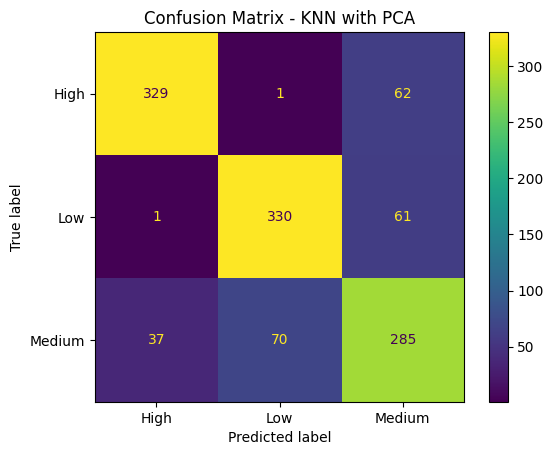

In [9]:

# TODO: Report and interpret the classification results.

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

# Classification report (readable labels)
print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred_labels))

ConfusionMatrixDisplay.from_predictions(
    y_test_labels,
    y_pred_labels
)

plt.title("Confusion Matrix - KNN with PCA")
plt.show()

# The model achieves a moderate accuracy on the test set.

# The classification report shows that performance is generally better for the majority class, while minority classes are slightly harder to predict.

# Precision and recall vary across classes, indicating that the model may struggle with overlapping feature distributions even after PCA.

# Overall, the combination of preprocessing, PCA, and KNN provides a reasonable baseline for customer value segmentation, but performance could potentially be improved with hyperparameter tuning or alternative models such as Random Forest or Gradient Boosting.

## Step 3: Product recommendation system

Here you will recommend products that are similar to a selected product based on product-level features.

Use PCA to simplify the feature space before computing nearest neighbors.

In [10]:

# TODO: Create a list of numeric product features to use for recommendations.
# Include only modeling features that describe product behavior/performance.
# Do NOT include identifiers or text-only columns such as StockCode or Description.
 
product_features = [
    "UnitPrice",
    "QuantitySold",
    "TotalRevenue",
    "TransactionCount",
    "UniqueCustomerCount",
    "AverageOrderValue",
    "PurchaseFrequency",
    "ReturnRate",
    "DiscountRate",
    "ProfitMargin"
]


In [11]:

# TODO: Scale the product features and reduce dimensionality with PCA.
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

product_features = product_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
print(product_features)


scaler_product = StandardScaler()
X_product_scaled = scaler_product.fit_transform(product_df[product_features])

pca_product = PCA(n_components=3)
X_product_pca = pca_product.fit_transform(X_product_scaled)

print("Explained variance ratio:", pca_product.explained_variance_ratio_)
print("Total variance explained:", sum(pca_product.explained_variance_ratio_))

['AvgUnitPrice', 'PriceStd', 'TotalUnitsSold', 'TotalRevenue', 'NumInvoices', 'UniqueCustomers', 'CountriesSoldTo', 'AvgQuantityPerInvoice', 'CustomerPenetration', 'RevenuePerCustomer', 'UnitsPerCustomer', 'InvoicePenetration']
Explained variance ratio: [0.47823254 0.25622972 0.14097462]
Total variance explained: 0.8754368847262788


In [12]:

# TODO: Fit a nearest-neighbors model on the PCA-transformed product features.
# Then choose one product and retrieve its nearest neighbors.

from sklearn.neighbors import NearestNeighbors

# Fit nearest neighbors model on PCA-transformed product features
nn_model = NearestNeighbors(n_neighbors=6, metric="euclidean")
nn_model.fit(X_product_pca)

# Query product index
query_index = 0

# Get nearest neighbors
distances, indices = nn_model.kneighbors([X_product_pca[query_index]])


## Step 4: Customer segmentation with clustering

You will cluster customers using behavioral features from the joined dataset.

The goal is to compare:
- **K-Means** for hard clustering
- **GMM** for probabilistic clustering

In [13]:

# TODO: Start from the joined dataset and remove extreme outliers.
# This helps prevent a very small number of unusual customers from dominating the clusters.

cluster_df = joined_df.copy()

# Remove extreme outliers using IQR on TotalSpend (or closest equivalent column)
Q1 = cluster_df["TotalSpend"].quantile(0.25)
Q3 = cluster_df["TotalSpend"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = (cluster_df["TotalSpend"] >= lower_bound) & (cluster_df["TotalSpend"] <= upper_bound)

cluster_df = cluster_df[mask].copy()

print("Rows used for clustering:", cluster_df.shape[0])

Rows used for clustering: 5250


In [14]:

# TODO: Build the clustering feature list.
# The share columns may vary depending on the prepared CSV version, so build them dynamically.

# Base clustering features
base_cluster_features = [
    "TotalUnits",
    "NumInvoices",
    "UniqueProducts",
    "CustomerTenureDays",
    "RecencyDays",
    "AvgUnitsPerInvoice",
    "PurchaseFrequency",
    "RecencyRatio",
    "DiversityRatio",
    "TopCategoryShare",
    "CategoryDiversity",
]

# Identify share-related columns dynamically (safe approach)
share_cols = [col for col in cluster_df.columns if "Share" in col]

# Final feature list (only keep columns that actually exist)
cluster_features = [
    col for col in base_cluster_features + share_cols
    if col in cluster_df.columns
]

print("Final clustering features:")
print(cluster_features)

Final clustering features:
['TotalUnits', 'UniqueProducts', 'CustomerTenureDays', 'RecencyDays', 'AvgUnitsPerInvoice', 'PurchaseFrequency', 'RecencyRatio', 'DiversityRatio', 'TopCategoryShare', 'CategoryDiversity', 'TopCategoryShare', 'Share_StorageBags', 'Share_GeneralGifts', 'Share_HomeDecor', 'Share_KitchenDining', 'Share_StationeryCrafts']


In [15]:

# TODO: Apply light transformations to reduce skew in the highest-volume variables.
# Then scale the data and apply PCA.

for col in [
    "TotalUnits",
    "NumInvoices",
    "UniqueProducts",
    "CustomerTenureDays",
    "RecencyDays",
    "AvgUnitsPerInvoice",
]:
    if col in cluster_df.columns:
        cluster_df[col] = np.log1p(cluster_df[col])


# Select clustering features
X_cluster = cluster_df[cluster_features]

# Scale data
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# PCA (commonly 2 or 3 components for clustering visualization)
pca_cluster = PCA(n_components=3)
X_cluster_pca = pca_cluster.fit_transform(X_cluster_scaled)

# Print PCA info
print("Number of PCA components:", pca_cluster.n_components_)
print("Explained variance ratio:", pca_cluster.explained_variance_ratio_)
print("Total variance retained:", sum(pca_cluster.explained_variance_ratio_))

Number of PCA components: 3
Explained variance ratio: [0.34562545 0.1284218  0.10450692]
Total variance retained: 0.5785541745205338


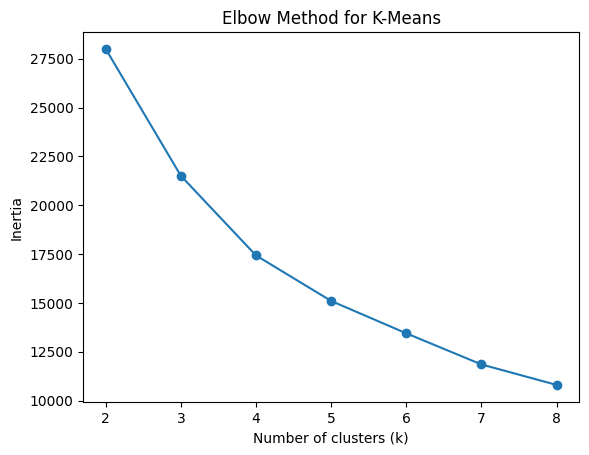

Chosen best_k: 3


In [16]:

# TODO: Use the elbow method to explore the best number of clusters for K-Means.

from sklearn.cluster import KMeans

inertias = []
k_values = range(2, 9)

# Fit KMeans for each k and store inertia
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_pca)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

# Choose best_k based on the "elbow" point where the curve starts to level off.
best_k = 3  # example (change based on your plot)
print("Chosen best_k:", best_k)

In [17]:

# TODO: Fit the final K-Means model using the k you selected from the elbow plot.
# Replace the value below after you inspect the plot.

from sklearn.cluster import KMeans

# Set this after checking your elbow plot (example: 3 is common)
best_k = 3  # change if your plot suggests otherwise

# Fit final KMeans model
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df["KMeansCluster"] = kmeans.fit_predict(X_cluster_pca)

# Check cluster distribution
print(cluster_df["KMeansCluster"].value_counts().sort_index())

KMeansCluster
0     818
1    1199
2    3233
Name: count, dtype: int64


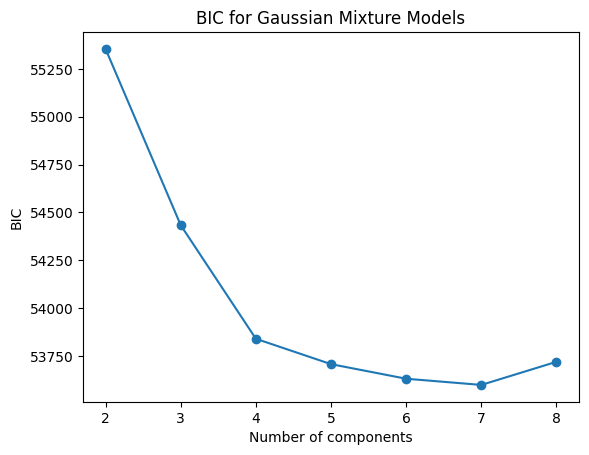

Best number of components (GMM): 7


In [18]:

# TODO: Use BIC to choose the number of components for GMM.
from sklearn.mixture import GaussianMixture

bic_scores = []
gmm_range = range(2, 9)

# Fit GMM for each number of components and compute BIC
for k in gmm_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_cluster_pca)
    bic_scores.append(gmm.bic(X_cluster_pca))

# Plot BIC curve
plt.plot(list(gmm_range), bic_scores, marker="o")
plt.xlabel("Number of components")
plt.ylabel("BIC")
plt.title("BIC for Gaussian Mixture Models")
plt.show()

# Choose best_gmm_n as the number of components with the lowest BIC.
best_gmm_n = gmm_range[np.argmin(bic_scores)]
print("Best number of components (GMM):", best_gmm_n)


In [19]:

# TODO: Fit the final GMM model using the number of components with the lowest BIC.
# Replace the value below after you inspect the BIC plot.

from sklearn.mixture import GaussianMixture

# Set this based on your BIC plot (example: often 3 or 4)
best_gmm_n = 3  # change if your BIC shows a different minimum

# Fit final GMM model
gmm_final = GaussianMixture(n_components=best_gmm_n, random_state=42)
cluster_df["GMMCluster"] = gmm_final.fit_predict(X_cluster_pca)

# Check cluster distribution
print(cluster_df["GMMCluster"].value_counts().sort_index())

GMMCluster
0    3227
1     669
2    1354
Name: count, dtype: int64


Columns in cluster_df: Index(['CustomerID', 'Country', 'FirstPurchaseDate', 'LastPurchaseDate',
       'NumInvoices_x', 'TotalUnits', 'TotalSpend', 'UniqueProducts',
       'FavoriteStockCode', 'FavoriteProductDescription', 'FavoriteCategory',
       'AvgOrderValue', 'RecencyDays', 'CustomerTenureDays',
       'AvgUnitsPerInvoice', 'SpendPerProduct', 'PurchaseFrequency',
       'RecencyRatio', 'DiversityRatio', 'TopCategoryShare',
       'CategoryDiversity', 'Share_StorageBags', 'Share_GeneralGifts',
       'Share_HomeDecor', 'Share_KitchenDining', 'Share_StationeryCrafts',
       'CountryGroup', 'ValueSegment', 'StockCode', 'Description', 'Category',
       'AvgUnitPrice', 'PriceStd', 'TotalUnitsSold', 'TotalRevenue',
       'NumInvoices_y', 'UniqueCustomers', 'CountriesSoldTo',
       'AvgQuantityPerInvoice', 'CustomerPenetration', 'RevenuePerCustomer',
       'UnitsPerCustomer', 'InvoicePenetration', 'KMeansCluster',
       'GMMCluster'],
      dtype='str')


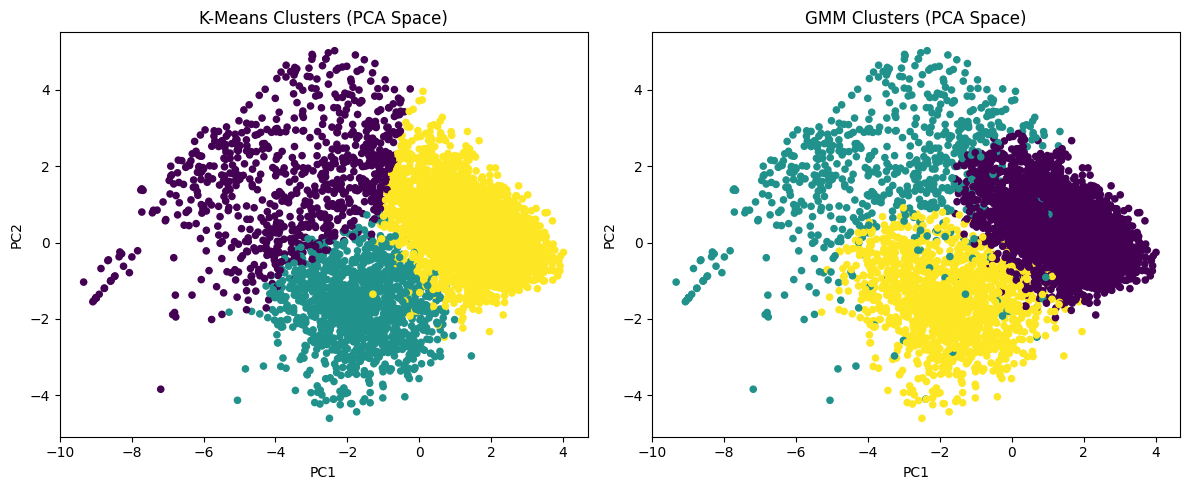

In [20]:

# TODO: Visualize the clusters using the first two principal components.

cluster_plot_df = pd.DataFrame(X_cluster_pca, columns=["PC1", "PC2", "PC3"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Ensure cluster columns exist
print("Columns in cluster_df:", cluster_df.columns)

cluster_plot_df = pd.DataFrame(X_cluster_pca[:, :2], columns=["PC1", "PC2"])

cluster_plot_df["KMeansCluster"] = cluster_df["KMeansCluster"].values
cluster_plot_df["GMMCluster"] = cluster_df["GMMCluster"].values

# KMeans plot
axes[0].scatter(
    cluster_plot_df["PC1"],
    cluster_plot_df["PC2"],
    c=cluster_plot_df["KMeansCluster"],
    cmap="viridis",
    s=20
)
axes[0].set_title("K-Means Clusters (PCA Space)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# GMM plot
axes[1].scatter(
    cluster_plot_df["PC1"],
    cluster_plot_df["PC2"],
    c=cluster_plot_df["GMMCluster"],
    cmap="viridis",
    s=20
)
axes[1].set_title("GMM Clusters (PCA Space)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

# Then create side-by-side scatterplots to compare the two clustering methods.

cluster_plot_df["KMeansCluster"] = cluster_df["KMeansCluster"].values
cluster_plot_df["GMMCluster"] = cluster_df["GMMCluster"].values


## Reflection questions

Answer these in markdown cells below the relevant sections.

1. Why was it important to remove variables like `TotalSpend` from the classification feature set?
2. How did PCA help in the classification, recommendation, and clustering tasks?
3. What differences do you notice between the K-Means and GMM clustering results?: -Means produces hard clusters, meaning each customer is assigned to exactly one group with clear, spherical boundaries. In contrast, GMM produces probabilistic clusters, allowing overlapping group membership and more flexible, elliptical cluster shapes. As a result, GMM often captures subtle structure in customer behavior better than K-Means, especially when clusters are not evenly shaped or well-separated.
4. Which customer or product insights seem the most actionable from a business perspective?